In [10]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc

import os

import scvi

import seaborn as sns

def order_m(m):
    n = min(*m.shape)

    ordered_cols = []
    remain_cols = list(range(m.shape[1]))

    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)

    return ordered_cols, remain_cols


canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]



In [11]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# Rename peakvi clustering columns
entropy_peak.obs['clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi']
peak.obs['clusters_peakvi_standard'] = peak.obs['clusters_peakvi']


# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')


## load peakvi models for DARS analysis 
standard_peak_model_dir = os.path.join(entropy_downstream_dir, 'standard_peak_peakvi_model')
entropy_peak_model_dir =os.path.join(entropy_downstream_dir, 'entropy_peak_peakvi_model')
standard_peak_model =scvi.model.PEAKVI.load(standard_peak_model_dir, adata=peak)
entropy_peak_model =scvi.model.PEAKVI.load(entropy_peak_model_dir, adata=entropy_peak)

INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/standard_peak_peakvi_mode
         l/model.pt already downloaded                                                                             


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [3]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2125 × 36729
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_entropy'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2125 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_standard'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1),
 (736320, 2))

## plot atac re-clustering with higher resolution

In [4]:
# atac clsutering at different resolutions (than previously used 0.2 in default)
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_highres_standard', resolution=atac_resolution)

/tmp/ipykernel_1055235/3470921404.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)


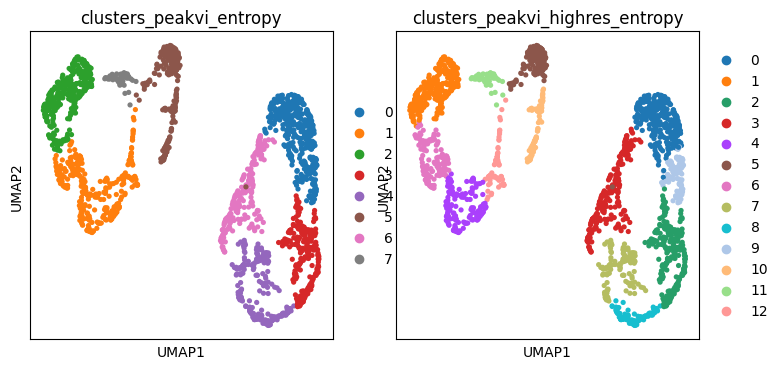

In [5]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(entropy_peak, color=['clusters_peakvi_entropy', 'clusters_peakvi_highres_entropy'], wspace=0.1)

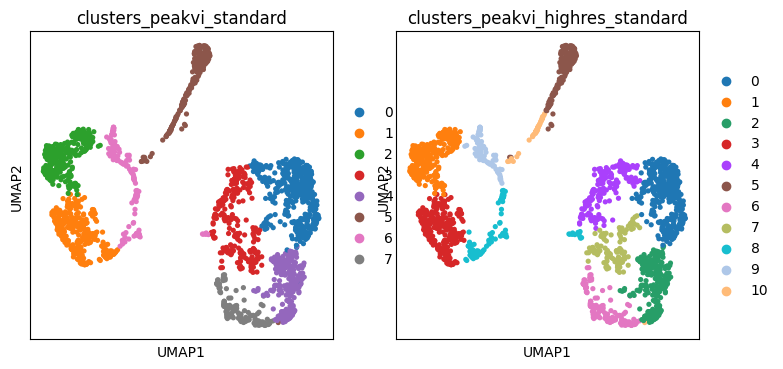

In [6]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(peak, color=[ 'clusters_peakvi_standard', 'clusters_peakvi_highres_standard'], wspace=0.1)

## Matching atac barcodes with RNA barcodes

In [8]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

# RNA clustering

In [9]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.columns = ['atac_bc']


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [10]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [11]:
# scvi.settings.seed = 0
# scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
# vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
# vae.train()
# h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()

# sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
# sc.tl.umap(h5_rna, min_dist=0.3)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(entropy_dir, "RNA_scvi_model")
# vae.save(vae_model_folder)
vae_model_folder=os.path.join(entropy_dir, "RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna)
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/RNA_scvi_model/model.pt already          
         downloaded                                                                                                


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [12]:
# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution + 0.1)

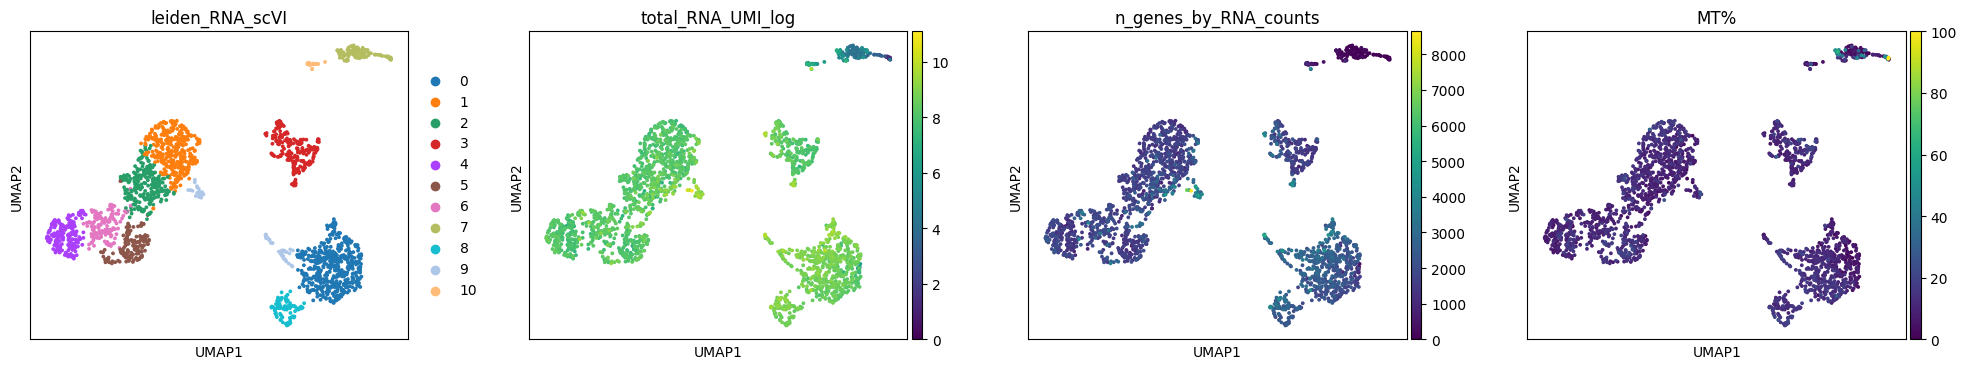

In [13]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=4)

## Cell-type annotaion from Juliana

In [ ]:
# Juliana's cell type annotation
RNAcluster_celltype_map = {
'0': 'CD14+ Mo',
'1': 'CD4+CD8+naiveTCells',
'2': 'Tregs',
'3': 'Bcells',
'4': 'ILC/NK Cells',
'5': 'MAIT/NKT Cells',
'6': 'gammaSignma Tcells',
'7': 'Unknown',
'8': 'CD16+ Mo',
'9': 'pDC',
'10': 'Plasma cells'
}

h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

## Plot to see consistency between atac space and rna space 

In [17]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_highres_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_entropy', axis=1, inplace=True)

if 'clusters_peakvi_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_standard', axis=1, inplace=True)
if 'clusters_peakvi_highres_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_standard', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'clusters_peakvi_highres_entropy']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_standard', 'clusters_peakvi_highres_standard']], left_on='atac_bc', right_index=True, how='left')

### Match ATAC (Standard-peak)-cluster and (Entropy-peak)-cluster by majority concordance

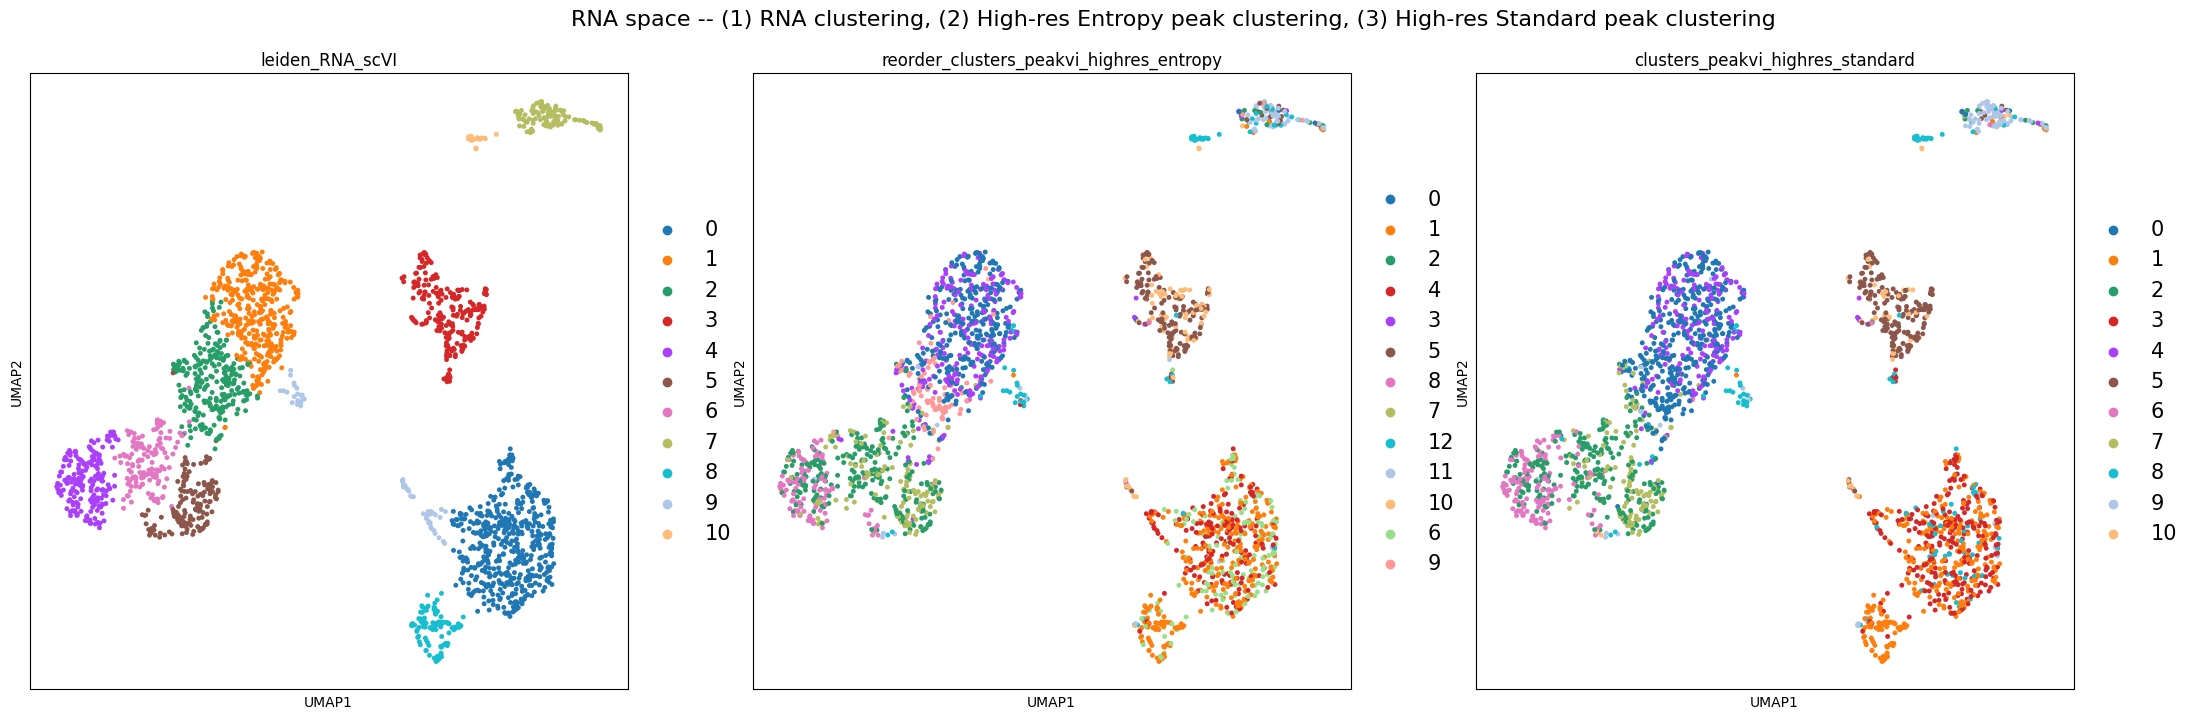

In [19]:
with plt.rc_context({'figure.figsize': (8, 8)}):
    axes = sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.1, ncols=3, size=50, legend_fontsize=15, show=False)
    plt.suptitle('RNA space -- (1) RNA clustering, (2) High-res Entropy peak clustering, (3) High-res Standard peak clustering', fontsize=16)
    
    plt.show()

## Project RNA cluster to ATAC space

In [22]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
if 'leiden_RNA_scVI' in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')

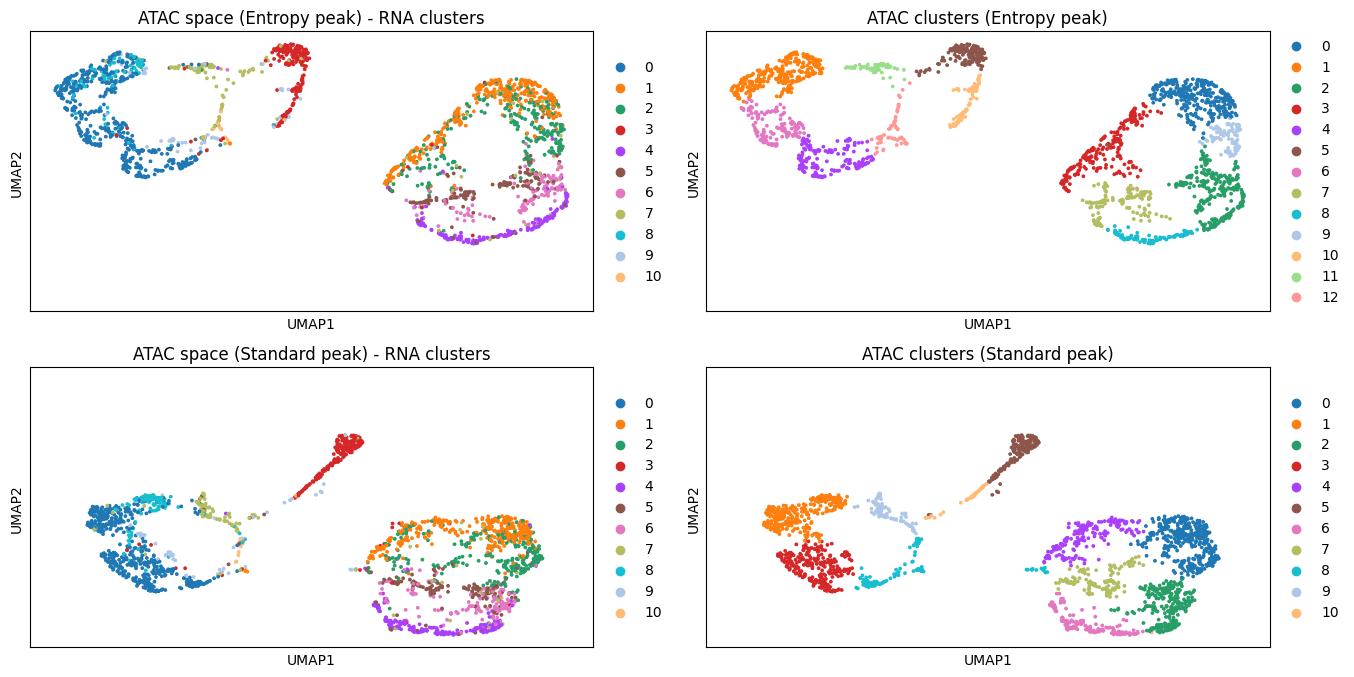

In [23]:
fig, ax = plt.subplots(2, 2, figsize=(16,8), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI'], title='ATAC space (Entropy peak) - RNA clusters', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['clusters_peakvi_highres_entropy'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)
sc.pl.umap(peak, color=['leiden_RNA_scVI'], title='ATAC space (Standard peak) - RNA clusters', size=30, ax=ax[2], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_highres_standard'], title='ATAC clusters (Standard peak)', size=30, ax=ax[3], show=True)

fig.tight_layout()

## DARs using RNA cluster (one cell type vs the rest of the cells)

In [24]:
standard_DARs = {}
for cluster in peak.obs['leiden_RNA_scVI'].unique():
    print(f" DARs on RNA-cluster {cluster}")
    standard_DARs[cluster] = standard_peak_model.differential_accessibility(
        groupby="leiden_RNA_scVI", group1=cluster,  two_sided=True
    )


 DARs on RNA-cluster 7
DE...: 100%|██████████| 1/1 [00:17<00:00, 17.63s/it]
 DARs on RNA-cluster 0
DE...: 100%|██████████| 1/1 [00:14<00:00, 14.65s/it]
 DARs on RNA-cluster 2
DE...: 100%|██████████| 1/1 [00:06<00:00,  6.75s/it]
 DARs on RNA-cluster 5
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.31s/it]
 DARs on RNA-cluster 6
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.82s/it]
 DARs on RNA-cluster 3
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.40s/it]
 DARs on RNA-cluster 9
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.99s/it]
 DARs on RNA-cluster 1
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.81s/it]
 DARs on RNA-cluster 4
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.92s/it]
 DARs on RNA-cluster 8
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.38s/it]
 DARs on RNA-cluster 10
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.39s/it]


In [25]:
entropy_DARs = {}
for cluster in entropy_peak.obs['leiden_RNA_scVI'].unique():
    print(f" DARs on RNA-cluster {cluster}")
    entropy_DARs[cluster] = entropy_peak_model.differential_accessibility(
        groupby="leiden_RNA_scVI", group1=cluster,  two_sided=True
    )

 DARs on RNA-cluster 7
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.38s/it]
 DARs on RNA-cluster 0
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.54s/it]
 DARs on RNA-cluster 2
DE...: 100%|██████████| 1/1 [00:06<00:00,  6.70s/it]
 DARs on RNA-cluster 5
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.74s/it]
 DARs on RNA-cluster 6
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.10s/it]
 DARs on RNA-cluster 3
DE...: 100%|██████████| 1/1 [00:04<00:00,  5.00s/it]
 DARs on RNA-cluster 9
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.98s/it]
 DARs on RNA-cluster 1
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.96s/it]
 DARs on RNA-cluster 4
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.00s/it]
 DARs on RNA-cluster 8
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.97s/it]
 DARs on RNA-cluster 10
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.08s/it]


## Load peak info -- (rediscovered, newly-discovred, or lost labels)

In [26]:
peak_comparison_dir = os.path.join(entropy_dir, 'peaks_comparison')
lost_peaks_anno_file = os.path.join(peak_comparison_dir, 'lost_peaks.bed')
newly_discovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'newly_discovered_peaks.bed')
recovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'recovered_peaks.bed')

In [27]:
lost_peaks_anno = pd.read_csv(lost_peaks_anno_file, header=None, sep='\t')  # Correspond to Standard peaks called using all the reads
newly_discovered_peaks_anno = pd.read_csv(newly_discovered_peaks_anno_file, header=None, sep='\t') # Correspond to Entropy peaks called using only the reads retained after entropy filtering
recovered_peaks_anno = pd.read_csv(recovered_peaks_anno_file, header=None, sep='\t') # In both peak sets [first half of the columns are from Standard peaks, second half from Entropy peaks]





lost_peaks_anno.index = lost_peaks_anno.apply(lambda x: f"{x[0]}:{x[1]}-{x[2]}", axis=1)
lost_peaks_anno.index.name = 'Standard_peak'

newly_discovered_peaks_anno.index = newly_discovered_peaks_anno.apply(lambda x: f"{x[0]}:{x[1]}-{x[2]}", axis=1)
newly_discovered_peaks_anno.index.name = 'Entropy_peak'

recovered_peaks_anno['Standard_peak'] = recovered_peaks_anno.apply(lambda x: f"{x[0]}:{x[1]}-{x[2]}", axis=1)
recovered_peaks_anno['Entropy_peak'] = recovered_peaks_anno.apply(lambda x: f"{x[10]}:{x[11]}-{x[12]}", axis=1)

In [28]:
lost_peaks_anno.head()

,0,1,2,3,4,5,6,7,8,9
Standard_peak,,,,,,,,,,
chr1:2663175-2663930,chr1,2663175,2663930,peak_134,342,.,257.992554,3.048749,-1,63
chr1:2664230-2665587,chr1,2664230,2665587,peak_135,371,.,503.672852,2.914509,-1,679
chr1:2671720-2672357,chr1,2671720,2672357,peak_136,436,.,277.447876,3.144313,-1,144
chr1:2748299-2748725,chr1,2748299,2748725,peak_138,501,.,213.434113,3.235945,-1,181
chr1:2756527-2757065,chr1,2756527,2757065,peak_139,509,.,273.738647,3.205816,-1,66


In [29]:
newly_discovered_peaks_anno.head()

,0,1,2,3,4,5,6,7,8,9
Entropy_peak,,,,,,,,,,
chr1:976091-976507,chr1,976091,976507,peak_37,718,.,298.735504,3.889666,-1,104
chr1:1079635-1080360,chr1,1079635,1080360,peak_48,378,.,273.890259,2.925810,-1,400
chr1:1099017-1099710,chr1,1099017,1099710,peak_49,560,.,388.208923,3.187139,-1,364
chr1:1216758-1217371,chr1,1216758,1217371,peak_59,352,.,215.751038,3.016410,-1,410
chr1:1440975-1441155,chr1,1440975,1441155,peak_72,1000,.,238.250076,3.859099,-1,82


In [30]:
recovered_peaks_anno.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,Standard_peak,Entropy_peak
0,chr1,817208,817719,peak_33,1000,.,885.841309,5.154950,-1,201,...,peak_29,1000,.,1076.525391,5.626947,-1,314,511,chr1:817208-817719,chr1:817095-817735
1,chr1,826857,828146,peak_34,1000,.,3416.727539,8.459686,-1,731,...,peak_30,1000,.,3954.990967,9.110417,-1,734,1289,chr1:826857-828146,chr1:826855-828152
2,chr1,869760,870205,peak_35,1000,.,824.793945,5.856312,-1,168,...,peak_31,1000,.,1009.061340,6.482105,-1,169,445,chr1:869760-870205,chr1:869759-870207
3,chr1,904403,905173,peak_36,1000,.,1179.364014,6.310306,-1,326,...,peak_32,1000,.,1400.115479,6.841542,-1,335,770,chr1:904403-905173,chr1:904394-905173
4,chr1,906808,907046,peak_37,1000,.,289.819641,3.906523,-1,82,...,peak_33,1000,.,368.910339,4.307466,-1,127,238,chr1:906808-907046,chr1:906808-907056


In [31]:
entropy_peak.var.head()

,peak
0,chr1:817095-817735
1,chr1:826855-828152
2,chr1:869759-870207
3,chr1:904394-905173
4,chr1:906808-907056


In [32]:
print( f'Entropy peaks total: {entropy_peak.shape[-1]}, \n \
    newly discovered: {entropy_peak.var["peak"].isin(newly_discovered_peaks_anno.index).sum()}, \n \
    lost: {entropy_peak.var["peak"].isin(lost_peaks_anno.index).sum()}, \n \
    recovered: {entropy_peak.var["peak"].isin(recovered_peaks_anno["Entropy_peak"]).sum()}' )

Entropy peaks total: 36729, 
     newly discovered: 6139, 
     lost: 0, 
     recovered: 30590


In [33]:
print( f'Peaks total: {peak.shape[-1]}, \n \
    newly discovered: {peak.var["peak"].isin(newly_discovered_peaks_anno.index).sum()}, \n \
    lost: {peak.var["peak"].isin(lost_peaks_anno.index).sum()}, \n \
    recovered: {peak.var["peak"].isin(recovered_peaks_anno["Standard_peak"]).sum()}' )

Peaks total: 31116, 
     newly discovered: 0, 
     lost: 35, 
     recovered: 31081


In [62]:
entropy_DARs['0'].head()

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2,Entropy_peak,lost_peak,newly_discovered_peak,recovered_peak,effect_size_correct_sign
3340,0.9868,True,4.314250,-0.480140,-0.195571,0.543804,0.063663,0.219917,0.024346,chr1:212488472-212488965,False,False,True,0.480140
14634,0.9860,True,4.254598,-0.554592,-0.277342,0.639592,0.085000,0.302905,0.025563,chr17:19386320-19387117,False,False,True,0.554592
8154,0.9860,True,4.254598,-0.596358,-0.280136,0.666407,0.070049,0.300830,0.020694,chr12:52203030-52203677,False,False,True,0.596358
28235,0.9852,True,4.198217,-0.477794,-0.209956,0.526465,0.048672,0.228216,0.018259,chr5:130764961-130765587,False,False,True,0.477794
1086,0.9850,True,4.184591,-0.581072,-0.288932,0.663082,0.082011,0.313278,0.024346,chr1:39934081-39934915,False,False,True,0.581072


## Check RNA-celltype DARs type [recovered, lost, or newly-discovered]
RNA cell-type is projected onto ATAC space, 
each cell-type's peaks are compared against all the rest of the cells

In [ ]:
# # Annotate DARs with peak type information
# for key in entropy_DARs.keys():

    id = entropy_DARs[key].index.values 
    entropy_DARs[key]['Entropy_peak'] = entropy_peak.var.loc[id, 'peak']
    entropy_DARs[key]['lost_peak'] = entropy_DARs[key]['Entropy_peak'].isin(lost_peaks_anno.index)
    entropy_DARs[key]['newly_discovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(newly_discovered_peaks_anno.index)
    entropy_DARs[key]['recovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(recovered_peaks_anno["Entropy_peak"])


for key in standard_DARs.keys():
    
    id = standard_DARs[key].index.values
    standard_DARs[key]['Standard_peak'] = peak.var.loc[id, 'peak']
    standard_DARs[key]['lost_peak'] = standard_DARs[key]['Standard_peak'].isin(lost_peaks_anno.index)
    standard_DARs[key]['newly_discovered_peak'] = standard_DARs[key]['Standard_peak'].isin(newly_discovered_peaks_anno.index)
    standard_DARs[key]['recovered_peak'] = standard_DARs[key]['Standard_peak'].isin(recovered_peaks_anno["Standard_peak"])
    

entropy_DARs_columns = entropy_DARs['0'].columns.to_list()
standard_DARs_columns = standard_DARs['0'].columns.to_list()
if 'chrom' not in entropy_DARs_columns:
    for cluster in entropy_DARs.keys():
        entropy_DARs[cluster]['chrom'] = entropy_DARs[cluster]['Entropy_peak'].apply(lambda x: x.split(':')[0])
        entropy_DARs[cluster]['start'] = entropy_DARs[cluster]['Entropy_peak'].apply(lambda x: int(x.split(':')[1].split('-')[0]))  
        entropy_DARs[cluster]['end'] = entropy_DARs[cluster]['Entropy_peak'].apply(lambda x: int(x.split('-')[1]))
        entropy_DARs[cluster] = entropy_DARs[cluster][['chrom', 'start', 'end'] + entropy_DARs_columns] # Reorder use for bed file 
if 'chrom' not in standard_DARs_columns:
    for cluster in standard_DARs.keys():
        standard_DARs[cluster]['chrom'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: x.split(':')[0])
        standard_DARs[cluster]['start'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: int(x.split(':')[1].split('-')[0]))  
        standard_DARs[cluster]['end'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: int(x.split('-')[1]))
        standard_DARs[cluster] = standard_DARs[cluster][['chrom', 'start', 'end'] + standard_DARs_columns]

        
# ## Save DARs results
# rna_cluster_DARs_dir = os.path.join(entropy_dir, '_rna_cluster_DARs')
# standard_DARs_dir = os.path.join(rna_cluster_DARs_dir, 'standard_peak_cluster_DARs')
# os.makedirs(standard_DARs_dir, exist_ok=True)

# for cluster in standard_DARs.keys():
#     all_dars_file = os.path.join(standard_DARs_dir, f'cluster_{cluster}_DARs.csv')
#     standard_DARs[cluster].to_csv(all_dars_file, index=False, sep='\t')
    
#     recovered_dars_file = os.path.join(standard_DARs_dir, f'cluster_{cluster}_DARs_in_recovered_peaks.csv')
#     standard_DARs[cluster].loc[standard_DARs[cluster]['recovered_peak']].to_csv(recovered_dars_file, index=False, sep='\t')
    
#     lost_dars_file = os.path.join(standard_DARs_dir, f'cluster_{cluster}_DARs_in_lost_peaks.csv')
#     standard_DARs[cluster].loc[standard_DARs[cluster]['lost_peak']].to_csv(lost_dars_file, index=False, sep='\t')
    
    
# entropy_DARs_dir = os.path.join(rna_cluster_DARs_dir, 'entropy_peak_cluster_DARs')
# os.makedirs(entropy_DARs_dir, exist_ok=True)
# for cluster in entropy_DARs.keys():
#     all_dars_file = os.path.join(entropy_DARs_dir, f'cluster_{cluster}_DARs.csv')
#     entropy_DARs[cluster].to_csv(all_dars_file, index=False, sep='\t')
    
#     recovered_dars_file = os.path.join(entropy_DARs_dir, f'cluster_{cluster}_DARs_in_recovered_peaks.csv')
#     entropy_DARs[cluster].loc[entropy_DARs[cluster]['recovered_peak']].to_csv(recovered_dars_file, index=False, sep='\t')
    
#     newly_discovered_dars_file = os.path.join(entropy_DARs_dir, f'cluster_{cluster}_DARs_in_newly_discovered_peaks.csv')
#     entropy_DARs[cluster].loc[entropy_DARs[cluster]['newly_discovered_peak']].to_csv(newly_discovered_dars_file, index=False, sep='\t')
    

# significant_standard_DARs_dir = os.path.join(rna_cluster_DARs_dir, 'significant_standard_peak_cluster_DARs')
# os.makedirs(significant_standard_DARs_dir, exist_ok=True)
# for cluster in standard_DARs.keys():
#     all_dars_file = os.path.join(significant_standard_DARs_dir, f'cluster_{cluster}_DARs.csv')
#     standard_DARs[cluster].loc[standard_DARs[cluster]['is_da_fdr']].to_csv(all_dars_file, index=False, sep='\t')
    
#     recovered_dars_file = os.path.join(significant_standard_DARs_dir, f'cluster_{cluster}_DARs_in_recovered_peaks.csv')
#     standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['recovered_peak'])].to_csv(recovered_dars_file, index=False, sep='\t')
    
#     lost_dars_file = os.path.join(significant_standard_DARs_dir, f'cluster_{cluster}_DARs_in_lost_peaks.csv')
#     standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['lost_peak'] )].to_csv(lost_dars_file, index=False, sep='\t')
    
    
# significant_entropy_DARs_dir = os.path.join(rna_cluster_DARs_dir, 'significant_entropy_peak_cluster_DARs')
# os.makedirs(significant_entropy_DARs_dir, exist_ok=True)
# for cluster in entropy_DARs.keys():
#     all_dars_file = os.path.join(significant_entropy_DARs_dir, f'cluster_{cluster}_DARs.csv')
#     entropy_DARs[cluster].loc[entropy_DARs[cluster]['is_da_fdr']].to_csv(all_dars_file, index=False, sep='\t')
    
#     recovered_dars_file = os.path.join(significant_entropy_DARs_dir, f'cluster_{cluster}_DARs_in_recovered_peaks.csv')
#     entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['recovered_peak'])].to_csv(recovered_dars_file, index=False, sep='\t')
    
#     newly_discovered_dars_file = os.path.join(significant_entropy_DARs_dir, f'cluster_{cluster}_DARs_in_newly_discovered_peaks.csv')
#     entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) &(entropy_DARs[cluster]['newly_discovered_peak'])].to_csv(newly_discovered_dars_file, index=False, sep='\t')
    


In [35]:
## Have to manually change effect-size sign 
# It's supposed to be positive for up-regulated DARs in the cluster according to their tutorial [est_prob1 - est_prob2], see: https://docs.scvi-tools.org/en/1.0.0/tutorials/notebooks/PeakVI.html#:~:text=effect_size,-is%20the%20effect
# However in their code:    "effect_size": result.scale2 - result.scale1, see: https://github.com/scverse/scvi-tools/blob/908476d4d8dab57b0462d4d3147b3ac42c42eadd/src/scvi/model/_peakvi.py#L514 .
# Can also see in our results: effect_size := est_prob1 - est_prob2 (but sign is reversed)

entropy_DARs['0'].loc[(entropy_DARs['4']['is_da_fdr']) ].head()

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2,Entropy_peak,lost_peak,newly_discovered_peak,recovered_peak
9952,0.9746,True,3.647278,-0.408425,-0.199911,0.569566,0.161141,0.251037,0.051126,chr13:113607305-113608087,False,False,True
22084,0.9736,True,3.607636,-0.519431,-0.234154,0.720629,0.201198,0.313278,0.079124,chr20:10673923-10675012,False,False,True
1398,0.9718,True,3.539828,-0.478945,-0.207406,0.670059,0.191114,0.278008,0.070603,chr1:59292600-59293054,False,False,True
27516,0.9634,True,3.270420,-0.559208,-0.257749,0.810967,0.251758,0.352697,0.094948,chr5:1501896-1502706,False,False,True
30329,0.9618,True,3.225971,-0.511940,-0.236944,0.834581,0.322641,0.356846,0.119903,chr6:106163448-106164936,False,False,True


In [36]:
## manually change effect-size sign 

for cluster in entropy_DARs.keys():
    entropy_DARs[cluster]['effect_size_correct_sign'] = -entropy_DARs[cluster]['effect_size']
    
for cluster in standard_DARs.keys():
    standard_DARs[cluster]['effect_size_correct_sign'] = -standard_DARs[cluster]['effect_size']

In [37]:
def create_DARs_stats(DARs_stats_dict, index_name):
    DAR_stats_df = pd.DataFrame(columns=['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks', 'DARs_in_newly_discovered_peaks'])
    
    for key in DARs_stats_dict.keys():
        NDAR_in_recovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'recovered_peak'].sum()
        NDAR_in_lost = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'lost_peak'].sum()
        NDAR_in_newly_discovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'newly_discovered_peak'].sum()
        
        DAR_stats_df.loc[key, 'total_DARs'] = DARs_stats_dict[key]['is_da_fdr'].sum()
        DAR_stats_df.loc[key, 'DARs_in_recovered_peaks'] = NDAR_in_recovered
        DAR_stats_df.loc[key, 'DARs_in_lost_peaks'] = NDAR_in_lost
        DAR_stats_df.loc[key, 'DARs_in_newly_discovered_peaks'] = NDAR_in_newly_discovered
        
    DAR_stats_df.index.name = index_name
    
    return DAR_stats_df



In [38]:
standard_DARs_stats = create_DARs_stats(standard_DARs, index_name='RNA_cluster_standard_peak')
entropy_DARs_stats = create_DARs_stats(entropy_DARs, index_name='RNA_cluster_entropy_peak')


standard_DARs_stats_perc = standard_DARs_stats.div(standard_DARs_stats['total_DARs'], axis=0) * 100
standard_DARs_stats_perc.columns = [col + '_perc' for col in standard_DARs_stats_perc.columns]
standard_DARs_stats_perc['total_DARs'] = standard_DARs_stats['total_DARs'] # add back total_DARs column for reference


entropy_DARs_stats_perc = entropy_DARs_stats.div(entropy_DARs_stats['total_DARs'], axis=0) * 100
entropy_DARs_stats_perc.columns = [col + '_perc' for col in entropy_DARs_stats_perc.columns]
entropy_DARs_stats_perc['total_DARs'] = entropy_DARs_stats['total_DARs'] # add back total_DARs column for reference

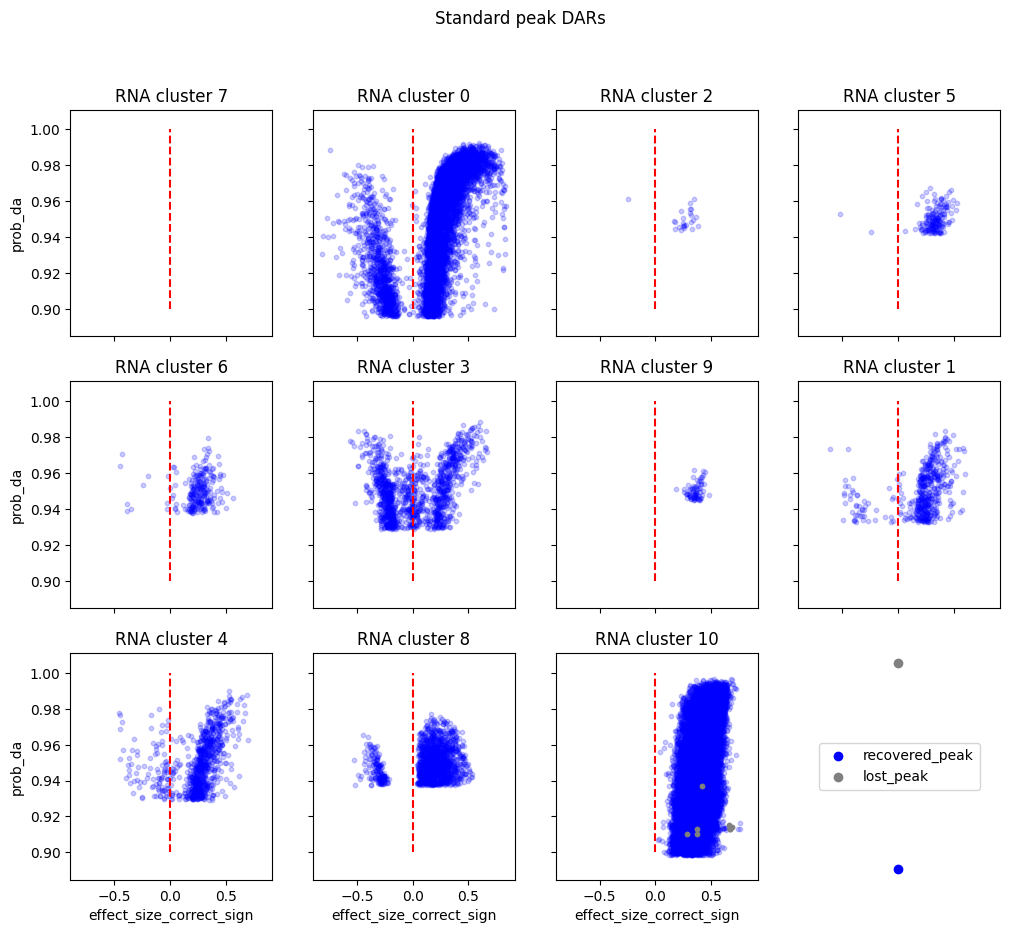

In [60]:
fig, axes = plt.subplots(3, 4, figsize=(12,10), sharex=True, sharey=True)
axes = axes.flatten()
for i, cluster in enumerate(standard_DARs.keys()):
    ax = axes[i]
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['recovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'RNA cluster {cluster}', s = 10, c='blue' , alpha=0.2 ) 
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['lost_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'RNA cluster {cluster}', s = 10, c='grey') 
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    
y_limit = axes[-1].get_ylim()
axes[-1].set_frame_on(False)
axes[-1].axes.get_yaxis().set_visible(False)
axes[-1].axes.get_xaxis().set_visible(False)
axes[-1].scatter(0, y_limit[0]  , marker='o', color='blue', label = 'recovered_peak')
axes[-1].scatter(0, y_limit[1] , marker='o', color='grey', label = 'lost_peak')
axes[-1].legend(loc = 'center')    

plt.suptitle('Standard peak DARs')

plt.show()

fig.savefig( os.path.join(DAR_w_RNAcluster_dir, 'DARs_per_RNA_cluster_standard_peakvi.png'), dpi=300) 

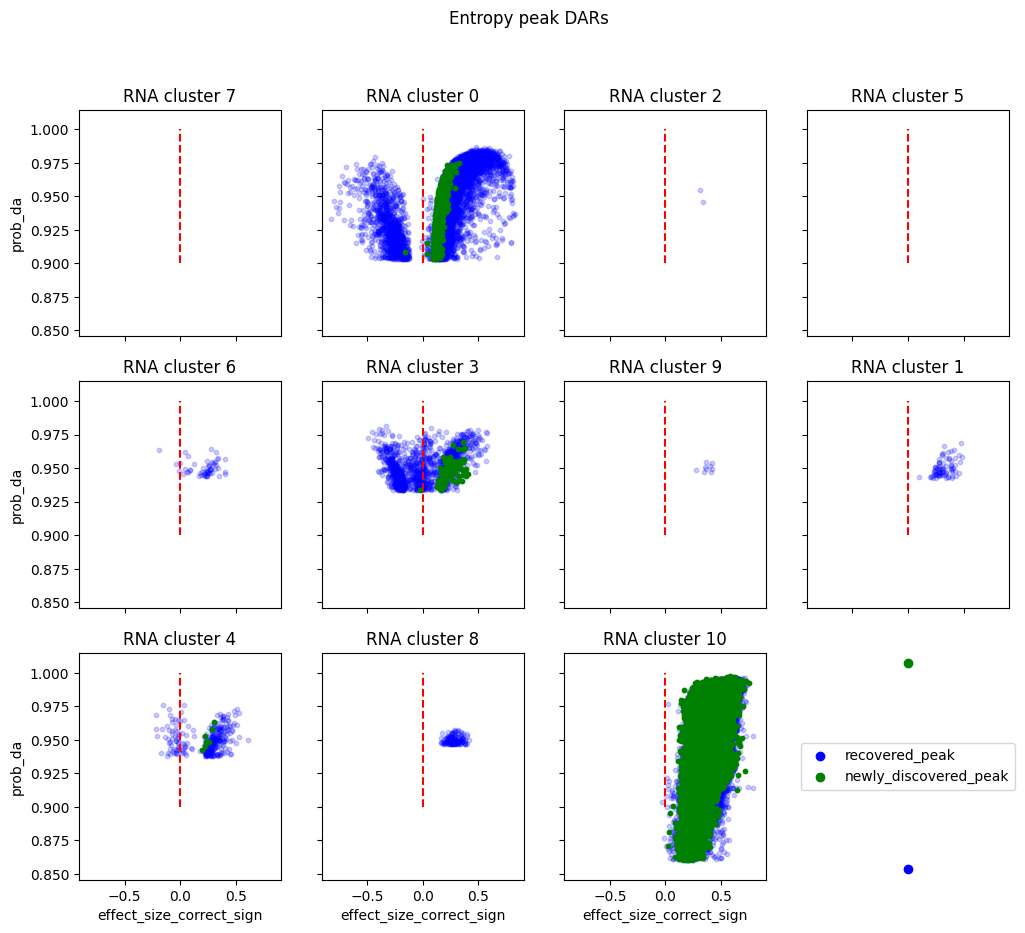

In [61]:
fig, axes = plt.subplots(3, 4, figsize=(12,10), sharex=True, sharey=True)
axes = axes.flatten()
for i, cluster in enumerate(entropy_DARs.keys()):
    ax = axes[i]
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['recovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'RNA cluster {cluster}', s=10, c='blue' , alpha=0.2) 
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['newly_discovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'RNA cluster {cluster}', s=10, c='green', alpha=1) 
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')


y_limit = axes[-1].get_ylim()
axes[-1].set_frame_on(False)
axes[-1].axes.get_yaxis().set_visible(False)
axes[-1].axes.get_xaxis().set_visible(False)
axes[-1].scatter(0, y_limit[0]  , marker='o', color='blue', label = 'recovered_peak')
axes[-1].scatter(0, y_limit[1] , marker='o', color='green', label = 'newly_discovered_peak')
axes[-1].legend(loc = 'center')
 
plt.suptitle('Entropy peak DARs')
 
plt.show()

fig.savefig( os.path.join(DAR_w_RNAcluster_dir, 'DARs_per_RNA_cluster_entropy_peakvi.png'), dpi=300) 

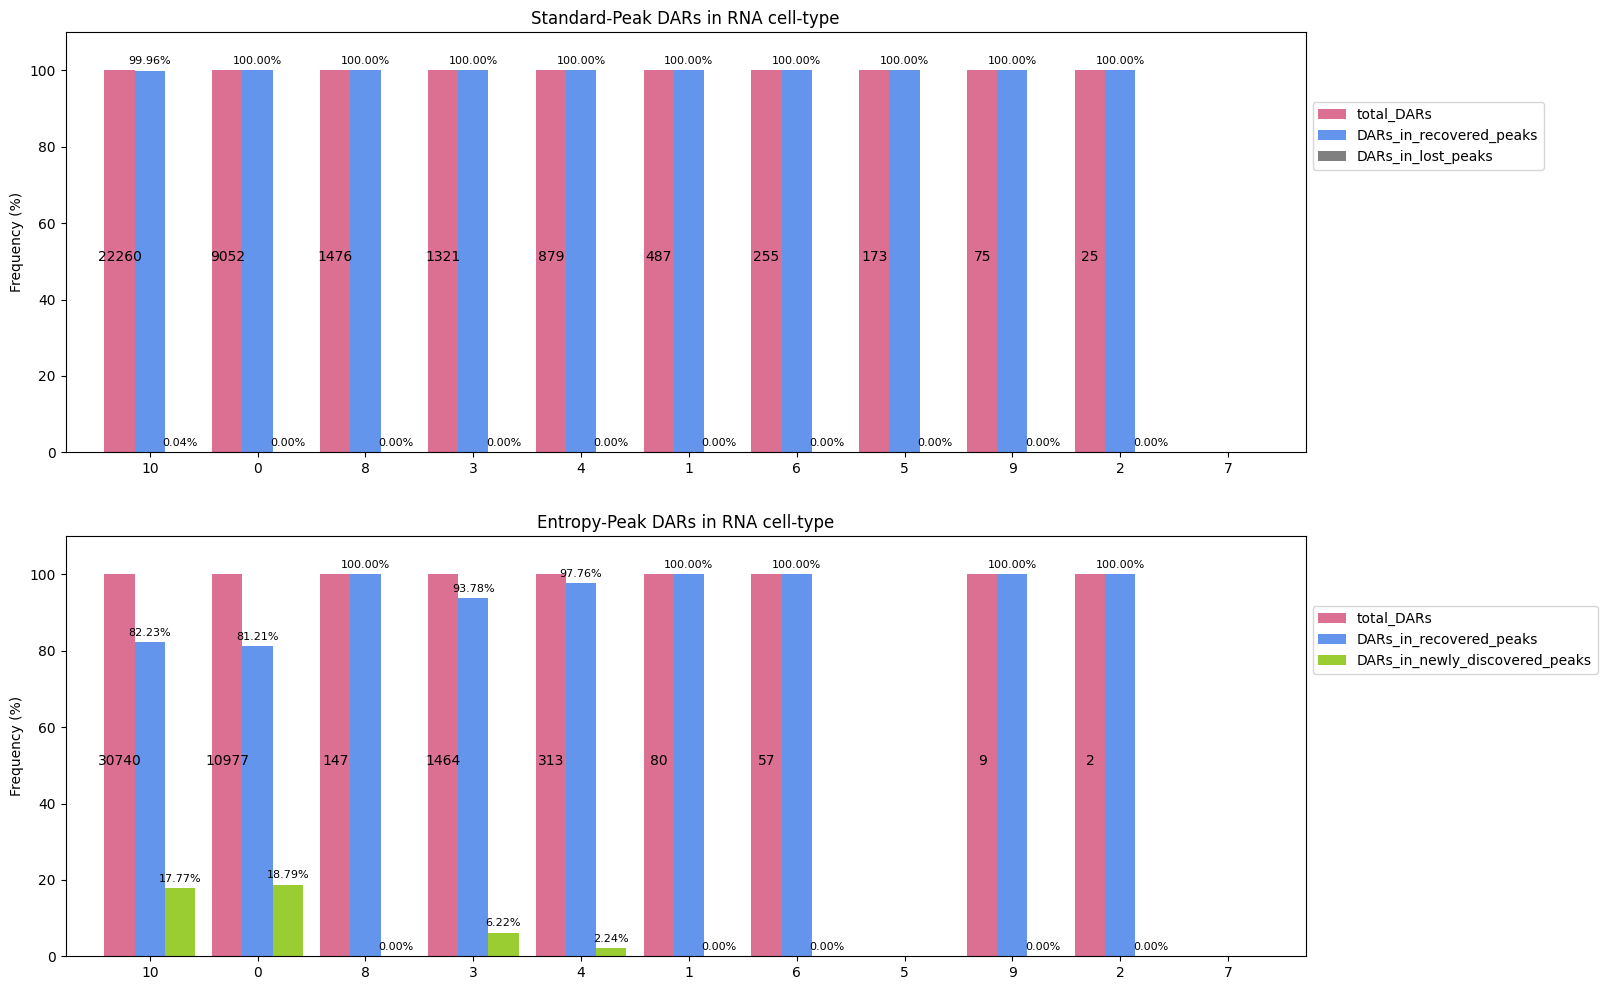

In [ ]:
plot_order_by_total_DARs = standard_DARs_stats['total_DARs'].sort_values(ascending=False, inplace=False).index.values

standard_DARs_stats2 = standard_DARs_stats.loc[plot_order_by_total_DARs, :]
standard_DARs_stats_perc2 = standard_DARs_stats_perc.loc[plot_order_by_total_DARs, :]
entropy_DARs_stats2 = entropy_DARs_stats.loc[plot_order_by_total_DARs, :]
entropy_DARs_stats_perc2 = entropy_DARs_stats_perc.loc[plot_order_by_total_DARs, :]

color_map = {'total_DARs': 'palevioletred', 'DARs_in_recovered_peaks': 'cornflowerblue', 'DARs_in_lost_peaks': 'grey', 'DARs_in_newly_discovered_peaks': 'yellowgreen'}

width = 0.28  # the width of the bars


fig, ax = plt.subplots(2, 1, figsize=(16,12))

# for attribute  in standard_DARs_stats.columns:
x = np.arange(standard_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks']:
    offset = width * multiplier
    rects = ax[0].bar(x + offset, standard_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = standard_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[0].bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos) 

    else:
        value_labels = standard_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[0].bar_label(rects, labels=[f'{x:,.2f}%' for x in value_labels] , padding=3, fontsize=8, label_type=value_pos) 

    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('Frequency (%)')
ax[0].set_title('Standard-Peak DARs in RNA cell-type')
ax[0].set_xticks(x + width, standard_DARs_stats2.index)
ax[0].set_xtickl
ax[0].set_xlim(-0.5, 11)
ax[0].legend(loc='upper left' , ncols=1, bbox_to_anchor=(1, 0.85) )
ax[0].set_ylim(0, 100 * 1.1)
y_labels = ax[0].get_yticklabels()
y_labels[-1].set_visible(False)


# for attribute  in entropy_DARs_stats.columns:
x = np.arange(entropy_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_newly_discovered_peaks']:
    offset = width * multiplier
    rects = ax[1].bar(x + offset, entropy_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = entropy_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[1].bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos) 

    else:
        value_labels = entropy_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[1].bar_label(rects, labels=[f'{x:,.2f}%' for x in value_labels] , padding=3, fontsize=8, label_type=value_pos) 

    multiplier += 1
    
# Add some text for labels, title and custom x-axis tick labels, etc.
ax[1].set_ylabel('Frequency (%)')
ax[1].set_title('Entropy-Peak DARs in RNA cell-type')     
ax[1].set_xticks(x + width, entropy_DARs_stats2.index)
ax[1].set_xlim(-0.5, 11)
ax[1].legend(loc='upper left' , ncols=1, bbox_to_anchor=(1, 0.85) )
ax[1].set_ylim(0, 100* 1.1)
y_labels = ax[1].get_yticklabels()
y_labels[-1].set_visible(False)

plt.show()



## Check peak specificiy to RNA cell-type

In [5]:
####
# For standard peaks
peak_at_RNAcluster_level = pd.DataFrame(index=peak.var['peak'], columns=peak.obs['leiden_RNA_scVI'].cat.categories)
for c in peak.obs['leiden_RNA_scVI'].cat.categories:
    a = peak[peak.obs['leiden_RNA_scVI'] == c, :].X.sum(axis=0 )
    peak_at_RNAcluster_level[c] = np.asarray(a).flatten()


peak_at_RNAcluster_level_h5ad = sc.AnnData(peak_at_RNAcluster_level.T)
# peak_at_RNAcluster_level_h5ad.obs['leiden_RNA_scVI'] = peak_at_RNAcluster_level.index
# peak_at_RNAcluster_level_h5ad.var['peak'] =peak_at_RNAcluster_level.index
peak_at_RNAcluster_level_h5ad.var['recovered'] = peak_at_RNAcluster_level_h5ad.var.index.isin(recovered_peaks_anno['Standard_peak'])
peak_at_RNAcluster_level_h5ad.var['lost'] = peak_at_RNAcluster_level_h5ad.var.index.isin(lost_peaks_anno.index)
peak_at_RNAcluster_level_h5ad.var['peak_type'] = peak_at_RNAcluster_level_h5ad.var.apply(lambda x: 'recovered' if x['recovered'] else ('lost' if x['lost'] else 'others'), axis=1)

####
# For entropy peaks
entropy_peak_at_RNAcluster_level = pd.DataFrame(index=entropy_peak.var['peak'], columns=entropy_peak.obs['leiden_RNA_scVI'].cat.categories)
for c in entropy_peak.obs['leiden_RNA_scVI'].cat.categories:
    a = entropy_peak[entropy_peak.obs['leiden_RNA_scVI'] == c, :].X.sum(axis=0 )
    entropy_peak_at_RNAcluster_level[c] = np.asarray(a).flatten()
    
entropy_peak_at_RNAcluster_level_h5ad = sc.AnnData(entropy_peak_at_RNAcluster_level.T)

entropy_peak_at_RNAcluster_level_h5ad.var['recovered'] = entropy_peak_at_RNAcluster_level_h5ad.var.index.isin(recovered_peaks_anno['Entropy_peak'])
entropy_peak_at_RNAcluster_level_h5ad.var['newly_discovered'] = entropy_peak_at_RNAcluster_level_h5ad.var.index.isin(newly_discovered_peaks_anno.index)
entropy_peak_at_RNAcluster_level_h5ad.var['peak_type'] = entropy_peak_at_RNAcluster_level_h5ad.var.apply(lambda x: 'recovered' if x['recovered'] else ('newly_discovered' if x['newly_discovered'] else 'others'), axis=1)


NameError: name 'pd' is not defined

In [43]:
peak_at_RNAcluster_level_h5ad.var['presence_in_Ngroups'] = (peak_at_RNAcluster_level_h5ad.X > 0).sum(axis=0)
entropy_peak_at_RNAcluster_level_h5ad.var['presence_in_Ngroups'] = (entropy_peak_at_RNAcluster_level_h5ad.X > 0).sum(axis=0)

In [44]:
peak_at_RNAcluster_level_h5ad.var.head()

,recovered,lost,peak_type,presence_in_Ngroups
peak,,,,
chr1:817208-817719,True,False,recovered,11
chr1:826857-828146,True,False,recovered,10
chr1:869760-870205,True,False,recovered,11
chr1:904403-905173,True,False,recovered,11
chr1:906808-907046,True,False,recovered,8


In [45]:
standard_peak_specificity = peak_at_RNAcluster_level_h5ad.var.groupby(['presence_in_Ngroups', 'peak_type']).size().unstack(fill_value=0)

entropy_peak_specificity = entropy_peak_at_RNAcluster_level_h5ad.var.groupby(['presence_in_Ngroups', 'peak_type']).size().unstack(fill_value=0)

standard_peak_specificity['total_peaks'] = standard_peak_specificity.sum(axis=1)
entropy_peak_specificity['total_peaks'] = entropy_peak_specificity.sum(axis=1)

NameError: name 'standard_peak_specificity' is not defined

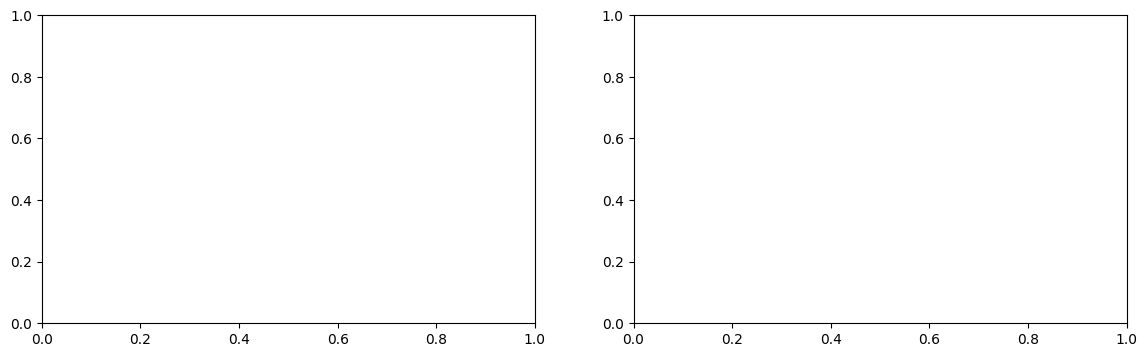

In [66]:
color_map = {'total_DARs': 'peru', 'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen'}


width = 0.8  # the width of the bars
fig, ax = plt.subplots( 1, 2, figsize=(14,4))

x = np.arange(standard_peak_specificity.shape[0])  # the label locations
bottom = np.zeros(standard_peak_specificity.shape[0])
for attribute  in [ 'lost', 'recovered']:

    y_perc = standard_peak_specificity[attribute] / standard_peak_specificity['total_peaks'] * 100
    rects = ax[0].bar(x , y_perc,  width, label=attribute, color=color_map[attribute], bottom=bottom)
    bottom += y_perc

    value_labels = standard_peak_specificity[attribute]
    value_pos = 'center'
    ax[0].bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos) 


# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('Frequency (%)')
# ax[0].set_title('Standard-Peak Specificity')
ax[0].set_xlabel('Number of cell-types where standard-peak is accessible', fontsize=10) 
ax[0].set_xticks(x , standard_peak_specificity.index)
ax[0].legend(loc='upper left',ncols=1, bbox_to_anchor=(1,1), fontsize=10)
ax[0].set_ylim(0, 100 * 1.2)
y_labels = ax[0].get_yticklabels()
y_labels[-1].set_visible(False)

x = np.arange(entropy_peak_specificity.shape[0])  # the label locations
bottom = np.zeros(entropy_peak_specificity.shape[0])
for attribute  in [ 'newly_discovered', 'recovered']:

    y_perc = entropy_peak_specificity[attribute] / entropy_peak_specificity['total_peaks'] * 100
    rects = ax[1].bar(x , y_perc,  width, label=attribute, color=color_map[attribute], bottom=bottom)
    bottom += y_perc
            
    value_labels = entropy_peak_specificity[attribute]
    value_pos = 'center'
    ax[1].bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos) 


# Add some text for labels, title and custom x-axis tick labels, etc.
ax[1].set_ylabel('Frequency (%)')
# ax[1].set_title('Entropy-Peak Specificity')    
ax[1].set_xlabel('Number of cell-types where entropy-peak is accessible', fontsize=10) 
ax[1].set_xticks(x, entropy_peak_specificity.index)
ax[1].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,1), fontsize=10)
ax[1].set_ylim(0, 100* 1.2)
y_labels = ax[1].get_yticklabels()
y_labels[-1].set_visible(False)

plt.show()

In [57]:
peak_at_RNAcluster_level_h5ad.var['peak_size'] = peak_at_RNAcluster_level_h5ad.var.index.map(lambda x: int(x.split(':')[1].split('-')[1]) - int(x.split(':')[1].split('-')[0]))
entropy_peak_at_RNAcluster_level_h5ad.var['peak_size'] = entropy_peak_at_RNAcluster_level_h5ad.var.index.map(lambda x: int(x.split(':')[1].split('-')[1]) - int(x.split(':')[1].split('-')[0]))

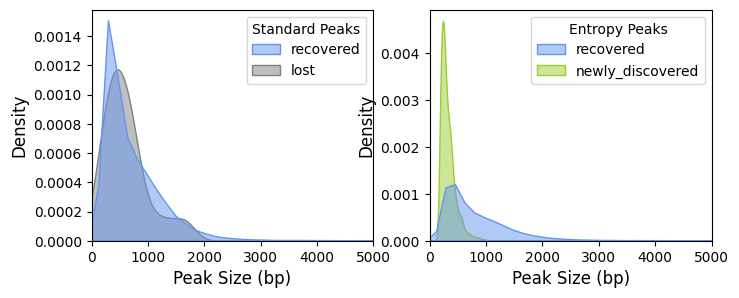

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(data=peak_at_RNAcluster_level_h5ad.var, x='peak_size', hue='peak_type', fill=True, common_norm=False, palette=['cornflowerblue', 'grey'], \
    alpha=0.5, ax=ax[0], )
sns.kdeplot(data=entropy_peak_at_RNAcluster_level_h5ad.var, x='peak_size', hue='peak_type', fill=True, common_norm=False, palette=['cornflowerblue', 'yellowgreen'], \
    alpha=0.5, ax=ax[1], )
# ax[0].set_title('Standard Peaks Size Distribution by Peak Type')
# ax[1].set_title('Entropy Peaks Size Distribution by Peak Type')
ax[0].set_xlim(0, 5000)
ax[1].set_xlim(0, 5000)
ax[0].set_xlabel('Peak Size (bp)', fontsize=12)
ax[1].set_xlabel('Peak Size (bp)', fontsize=12)
ax[0].set_ylabel('Density', fontsize=12)
ax[1].set_ylabel('Density', fontsize=12)
sns.move_legend(ax[0], title="Standard Peaks", loc='upper right')
sns.move_legend(ax[1], title="Entropy Peaks", loc='upper right')
plt.show()

### Alluvial plot

In [97]:
import pyalluvial.alluvial as alluvial

In [117]:
standard_peak_celltype_specific_peaks = peak_at_RNAcluster_level_h5ad.var[peak_at_RNAcluster_level_h5ad.var['presence_in_Ngroups'] == 1].copy()
standard_peak_celltype_specific_peaks['peak_name'] = standard_peak_celltype_specific_peaks.index.values


for peak_name in standard_peak_celltype_specific_peaks.index:
    
    RNA_cluster_index = peak_at_RNAcluster_level_h5ad.X[:, peak_at_RNAcluster_level_h5ad.var.index == peak_name].flatten().nonzero()[0][0]
    freq = peak_at_RNAcluster_level_h5ad.X[:, peak_at_RNAcluster_level_h5ad.var.index == peak_name].flatten()[RNA_cluster_index]
    RNA_cluster = peak_at_RNAcluster_level_h5ad.obs.index[RNA_cluster_index]
    standard_peak_celltype_specific_peaks.loc[peak_name, 'presence_in_RNA_cluster'] = RNA_cluster
    standard_peak_celltype_specific_peaks.loc[peak_name, 'freq'] = freq
    


entropy_peak_celltype_specific_peaks = entropy_peak_at_RNAcluster_level_h5ad.var[entropy_peak_at_RNAcluster_level_h5ad.var['presence_in_Ngroups'] == 1].copy()
entropy_peak_celltype_specific_peaks['peak_name'] = entropy_peak_celltype_specific_peaks.index.values

for peak_name in entropy_peak_celltype_specific_peaks.index:
    
    RNA_cluster_index = entropy_peak_at_RNAcluster_level_h5ad.X[:, entropy_peak_at_RNAcluster_level_h5ad.var.index == peak_name].flatten().nonzero()[0][0]
    freq = entropy_peak_at_RNAcluster_level_h5ad.X[:, entropy_peak_at_RNAcluster_level_h5ad.var.index == peak_name].flatten()[RNA_cluster_index]
    RNA_cluster = entropy_peak_at_RNAcluster_level_h5ad.obs.index[RNA_cluster_index]
    entropy_peak_celltype_specific_peaks.loc[peak_name, 'presence_in_RNA_cluster'] = RNA_cluster
    entropy_peak_celltype_specific_peaks.loc[peak_name, 'freq'] = freq
    

In [ ]:
entropy_peak_celltype_specific_peaks.head()

,recovered,newly_discovered,peak_type,presence_in_Ngroups,peak_name,presence_in_RNA_cluster,freq
peak,,,,,,,
chr1:1699846-1700687,True,False,recovered,1,chr1:1699846-1700687,10,1.0
chr1:16585510-16585930,True,False,recovered,1,chr1:16585510-16585930,10,3.0
chr1:16700546-16701562,True,False,recovered,1,chr1:16700546-16701562,2,1.0
chr1:16703250-16703601,False,True,newly_discovered,1,chr1:16703250-16703601,5,1.0
chr1:120664784-120665693,True,False,recovered,1,chr1:120664784-120665693,9,1.0


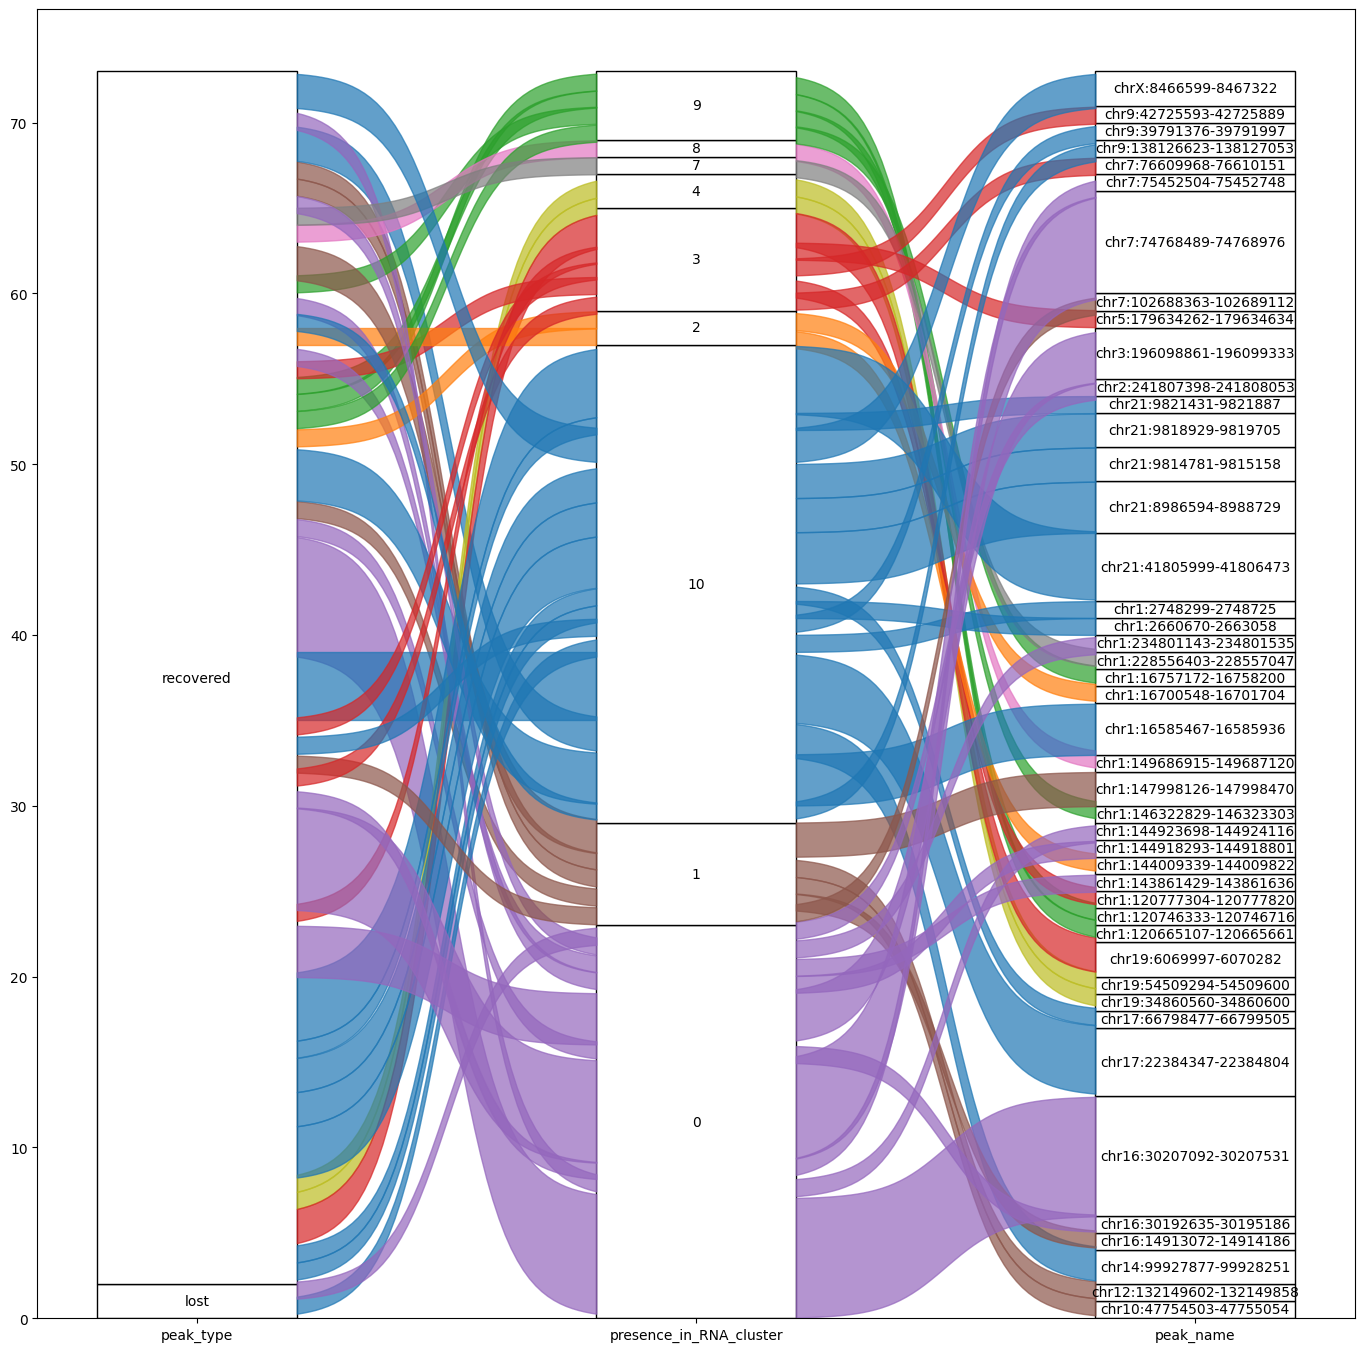

In [147]:
fig = alluvial.plot(
   df=standard_peak_celltype_specific_peaks, 
   xaxis_names=['peak_type', 'presence_in_RNA_cluster', 'peak_name'], 
   y_name='freq', 
   alluvium='presence_in_RNA_cluster',
   order_dict={'peak_type': ['lost', 'recovered']}, 
   figsize = (17, 17) 
)
   

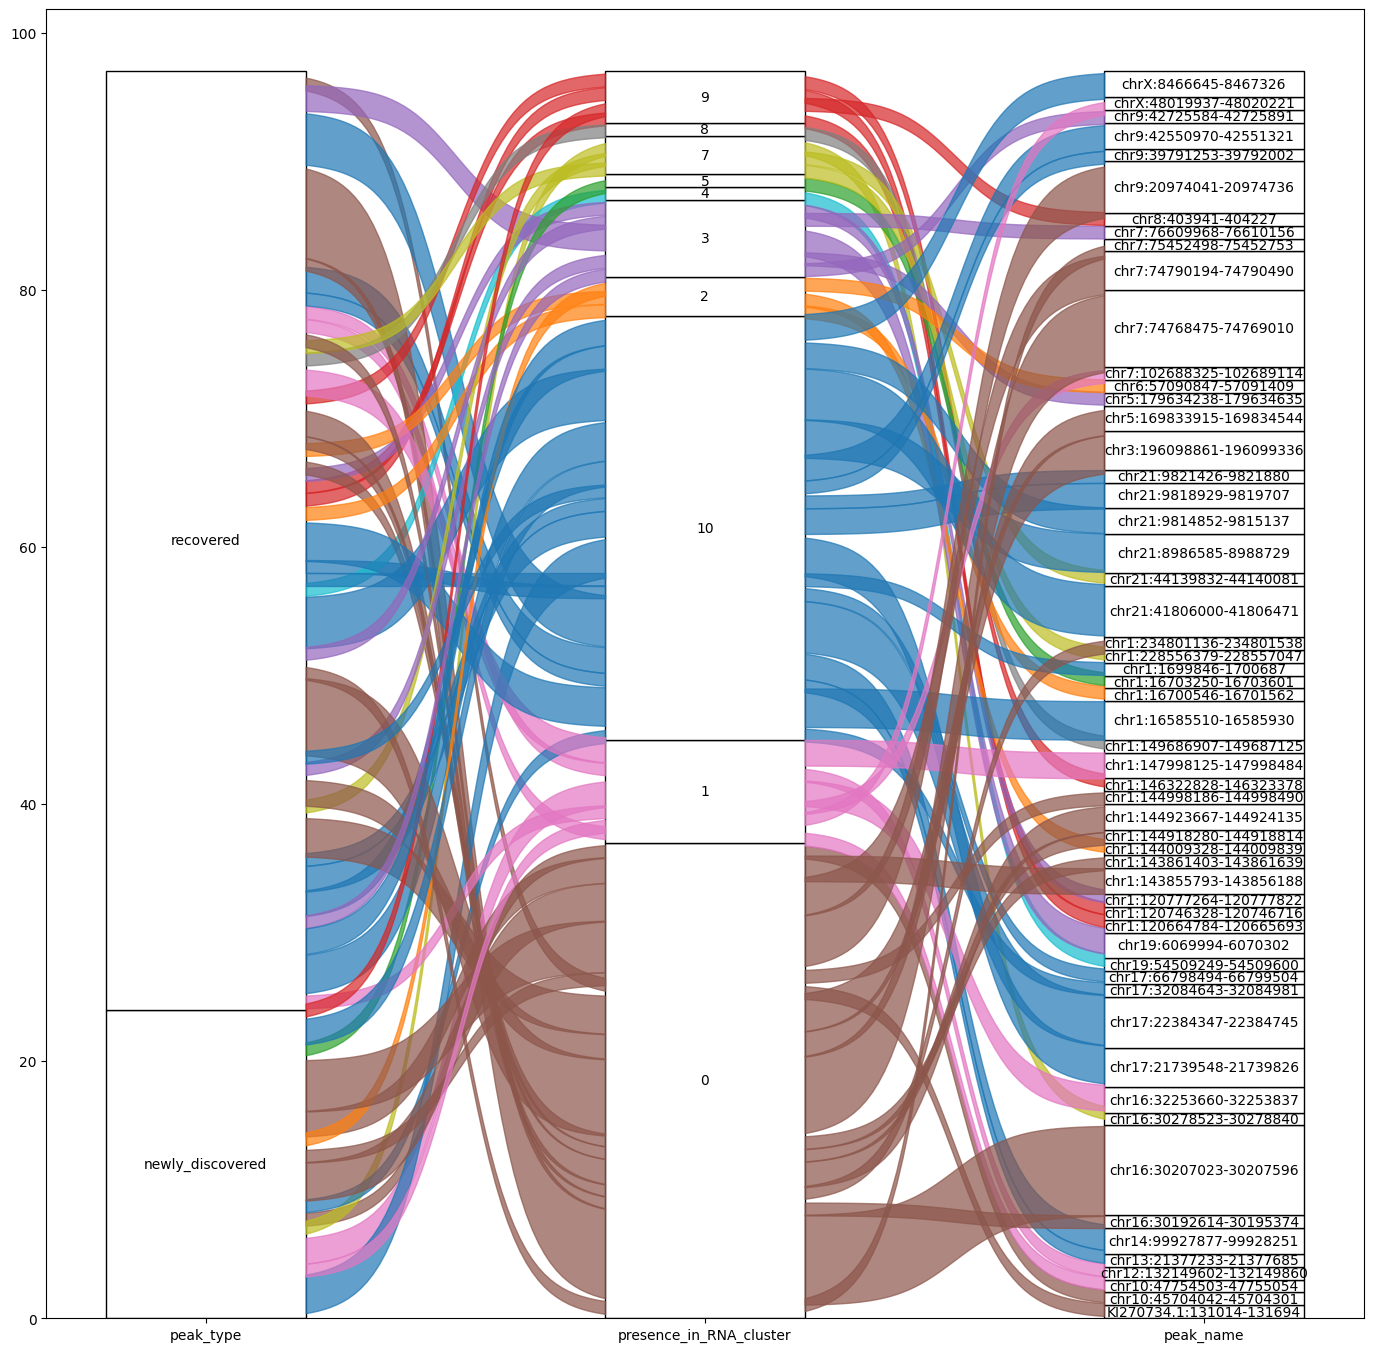

In [144]:
fig = alluvial.plot(
   df=entropy_peak_celltype_specific_peaks, 
   xaxis_names=['peak_type', 'presence_in_RNA_cluster', 'peak_name'], 
   y_name='freq', 
   alluvium='presence_in_RNA_cluster',
   order_dict={'peak_type': ['newly_discovered', 'recovered']}, 
   figsize = (17, 17) 
   
)

In [ ]:
alluvial_standardpeaks = standard_peak_celltype_specific_peaks.groupby(['peak_type', 'presence_in_RNA_cluster'], as_index=False).size().fillna(0)
alluvial_entropypeaks = entropy_peak_celltype_specific_peaks.groupby(['peak_type', 'presence_in_RNA_cluster'], as_index=False).size().fillna(0)

In [1]:
# fig = alluvial.plot(
#    df=alluvial_entropypeaks, 
#    xaxis_names=['peak_type', 'presence_in_RNA_cluster'], 
#    y_name='size', 
#    alluvium='presence_in_RNA_cluster',
#    figsize = (7, 10)
   
# )

In [2]:
# fig = alluvial.plot(
#    df=alluvial_standardpeaks, 
#    xaxis_names=['peak_type', 'presence_in_RNA_cluster'], 
#    y_name='size', 
#    alluvium='presence_in_RNA_cluster',
#    figsize = (7, 7)
# )